In [25]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import scipy.stats as stats

### temporal-difference agent (q-learning, SARSA)
class TDAgent:
    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.99, epsilon=0.1, mode='q-learning'):
        self.q_table = np.zeros((n_states, n_actions))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.mode = mode
        self.n_actions = n_actions

    def select_action(self, state, rng):
        if rng.random() < self.epsilon:
            return int(rng.choice(np.arange(self.n_actions)))
        return int(np.argmax(self.q_table[state]))

    def update(self, s, a, r, s_next, a_next, terminated):
        if self.mode == 'q-learning':
            target = r + self.gamma * np.max(self.q_table[s_next]) * (not terminated)
        else:
            target = r + self.gamma * self.q_table[s_next, a_next] * (not terminated)
        self.q_table[s, a] += self.alpha * (target - self.q_table[s, a])

def run_experiment(mode, n_seeds=30, n_episodes=500):
    all_returns = np.zeros((n_seeds, n_episodes))
    final_agent = None # initialize for visualization
    
    for seed in tqdm(range(n_seeds), desc=f"Training {mode}"):
        env = gym.make('CliffWalking-v1')
        rng = np.random.default_rng(seed)
        agent = TDAgent(48, 4, mode=mode)
        
        for ep in range(n_episodes):
            state, _ = env.reset(seed=seed+ep)
            action = agent.select_action(state, rng)
            total_reward = 0
            while True:
                next_state, reward, terminated, truncated, _ = env.step(action)
                next_action = agent.select_action(next_state, rng)
                agent.update(state, action, reward, next_state, next_action, terminated)
                state, action = next_state, next_action
                total_reward += reward
                if terminated or truncated: break
            all_returns[seed, ep] = total_reward
        
        final_agent = agent # keep the last trained agent
        env.close()
    return all_returns, final_agent

def visualize_comparison(sarsa_agent, q_agent):
    rows, cols = 4, 12
    fig, axes = plt.subplots(2, 1, figsize=(15, 8))
    
    agents = [
        (sarsa_agent.q_table, "SARSA Learned Policy (Safe Path)", axes[0]),
        (q_agent.q_table, "Q-Learning Learned Policy (Optimal Path)", axes[1])
    ]

    for q_table, title, ax in agents:
        # Derive State Values (V) and Greedy Policy (Pi)
        v = np.max(q_table, axis=1).reshape(rows, cols)
        pi = np.argmax(q_table, axis=1).reshape(rows, cols)
        
        ### plot heatmap
        im = ax.imshow(v, cmap='RdYlGn', interpolation='nearest', vmin=-20, vmax=-1)
        
        # Policy Arrows (with corrected y values)
        arrow_map = {0: (0, -0.35), 1: (0.35, 0), 2: (0, 0.35), 3: (-0.35, 0)}
        
        for r in range(rows):
            for c in range(cols):
                if r == 3 and 0 < c < 11: continue # Cliff
                if r == 3 and c == 11: continue    # Goal
                
                action = pi[r, c]
                dx, dy = arrow_map[action]
                ax.arrow(c, r, dx, dy, head_width=0.15, head_length=0.15, fc='black', ec='black')

        # Annotate S, G, and Cliff
        ax.text(0, 3, 'S', ha='center', va='center', fontsize=16, fontweight='bold')
        ax.text(11, 3, 'G', ha='center', va='center', fontsize=16, fontweight='bold')
        for c_idx in range(1, 11):
            ax.text(c_idx, 3, 'X', ha='center', va='center', color='white', fontweight='bold')

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xticks(range(cols))
        ax.set_yticks(range(rows))

    # Single colorbar for the whole figure
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='State Value (V)')

    plt.savefig('heatmaps.png', bbox_inches='tight')
    plt.show()

def plot_learning_curves(sarsa_data, ql_data):
    plt.figure(figsize=(10, 6))
    
    for data, label, color in [(sarsa_data, 'SARSA', '#27ae60'), (ql_data, 'Q-Learning', '#e74c3c')]:
        # Calculate the components
        mean = np.mean(data, axis=0) 
        sem = stats.sem(data, axis=0)
        df = data.shape[0] - 1 # degrees of freedom (assuming sample population, not infinite distribution)

        print(f'Maximum ({label}): {mean.max()}')

        ### confidence intervals
        low, high = stats.t.interval(confidence=0.95, df=df, loc=mean, scale=sem)
        ci = high - mean
        
        # Smooth the lines for better readability
        window = 10
        mean_smoothed = np.convolve(mean, np.ones(window)/window, mode='valid')
        ci_smoothed = np.convolve(ci, np.ones(window)/window, mode='valid')
        x = np.arange(len(mean_smoothed))
        
        plt.plot(x, mean_smoothed, label=label, color=color, lw=2)
        plt.fill_between(x, mean_smoothed - ci_smoothed, mean_smoothed + ci_smoothed, color=color, alpha=0.2)

    plt.axhline(-13, color='black', linestyle='--', alpha=0.5, label='Optimal Path (-13)')
    plt.title("Learning Curves: SARSA vs Q-Learning (30 Seeds)", fontsize=14, fontweight='bold')
    plt.xlabel("Episode", fontsize=12)
    plt.ylabel("Sum of Rewards", fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.savefig('training.png')
    plt.show()

Maximum (SARSA): -17.0
Maximum (Q-Learning): -22.1


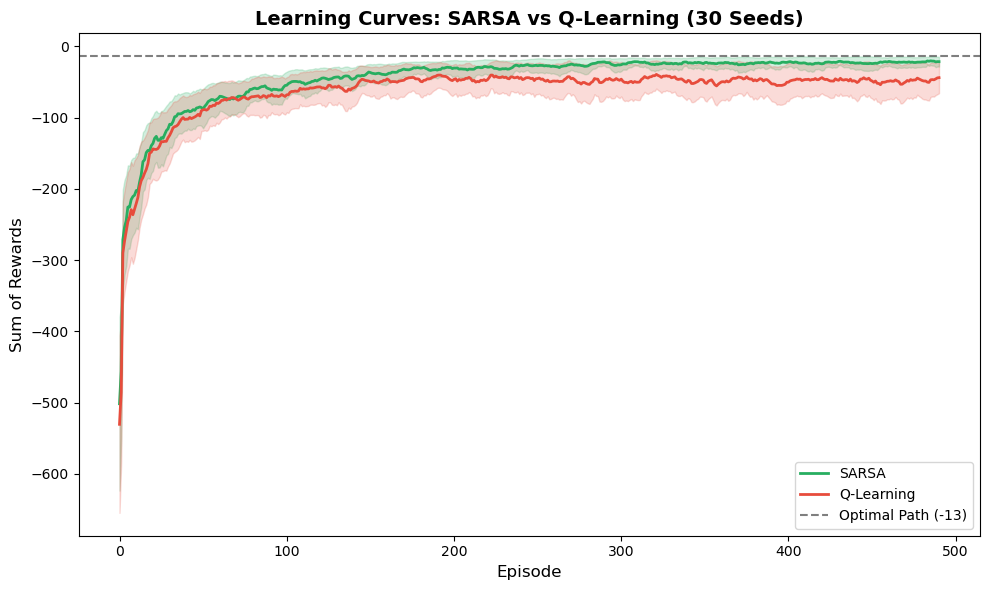

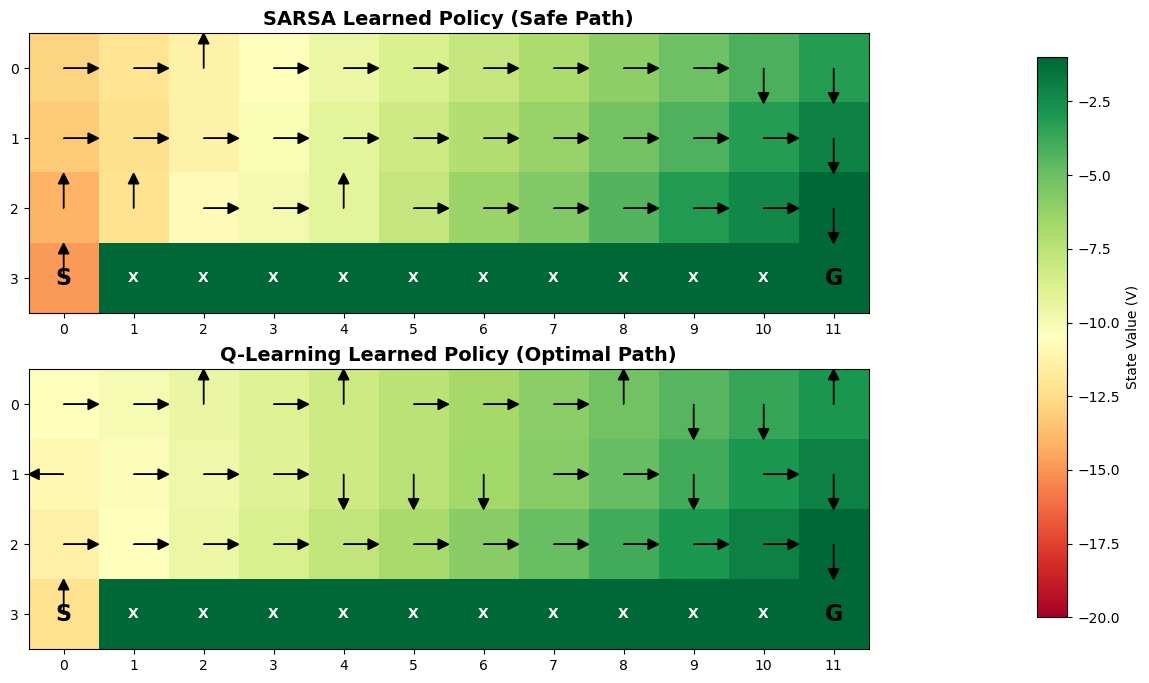

In [29]:
# ### training
sarsa_results, sarsa_agent = run_experiment('sarsa')
q_results, q_agent = run_experiment('q-learning')

# ### training curves
plot_learning_curves(sarsa_results, q_results)

### policy visualization
visualize_comparison(sarsa_agent, q_agent)

In [30]:
print('Q-values for state 35 (Above Goal):')
print(f'Up: {q_agent.q_table[35, 0]:.2f}')
print(f'Right: {q_agent.q_table[35, 1]:.2f}')
print(f'Down: {q_agent.q_table[35, 2]:.2f}')
print(f'Left: {q_agent.q_table[35, 3]:.2f}')

Q-values for state 35 (Above Goal):
Up: -2.42
Right: -1.83
Down: -1.00
Left: -2.55
